# End-to-end Machine Learning (MLflow + Docker + Google cloud)

This is an account of my learning journey aided by [this](https://mlflow.org/docs/latest/ml/getting-started/hyperparameter-tuning/) tutorial to grasp the nitty-gritties of buliding, logging, saving and serving machine learning models. First is a description of the development environment used.

## Development Environment

I am running Debian 24.04 LTS, and Pycharm IDE calling Python 3.12 within a .venv virtual environment. Since the model used is a Tensorflow neural network, I had to follow [cuda](https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=deb_local) documentation in setting up necessary drives. You also need to start mlflow ui local server by running `mlflow ui --port 5000` in the terminal, install dependenices `pip install mlflow[extras] hyperopt tensorflow scikit-learn pandas numpy`, and set environment variable `export MLFLOW_TRACKING_URI=http://localhost:5000`.

## Step 1 : Data Preparation

The tutorial uses [wine quality](https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-white.csv) classification data.

```
# prepare data

import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
import mlflow
from mlflow.models import infer_signature
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# test prediction
import requests
import json

# environment variables
load_dotenv(".env")

MLFLOW_TRACKING_URI=os.getenv("MLFLOW_TRACKING_URI")
XLA_FLAGS=os.getenv('XLA_FLAGS')

# load data
data = pd.read_csv(
    "https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-white.csv",
    sep=";",
)

train, test = train_test_split(data, test_size=0.2, random_state=12)
train_x = train.drop(["quality"], axis=1).values
train_y = train[["quality"]].values.ravel()
test_x = test.drop(["quality"], axis=1).values
test_y = test[["quality"]].values.ravel()

# further split training data for validation
train_x, valid_x, train_y, valid_y = train_test_split(train_x, train_y, test_size=0.2, random_state=12)

# Create model signature for deployment
signature = infer_signature(train_x, train_y)

```

## Define Model architecture

```
def create_and_train_model(learning_rate, momentum, epochs=10):
    """
    Create and train a neural network with specified hyperparameters.

    Returns:
        dict: Training results including model and metrics
    """
    # Normalize input features for better training stability
    mean = np.mean(train_x, axis=0)
    var = np.var(train_x, axis=0)

    # Define model architecture
    model = keras.Sequential(
        [
            keras.Input([train_x.shape[1]]),
            keras.layers.Normalization(mean=mean, variance=var),
            keras.layers.Dense(64, activation="relu"),
            keras.layers.Dropout(0.2),  # Add regularization
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(1),
        ]
    )

    # Compile with specified hyperparameters
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum),
        loss="mean_squared_error",
        metrics=[keras.metrics.RootMeanSquaredError()],
    )

    # Train with early stopping for efficiency
    early_stopping = keras.callbacks.EarlyStopping(
        patience=3, restore_best_weights=True
    )

    # Train the model
    history = model.fit(
        train_x,
        train_y,
        validation_data=(valid_x, valid_y),
        epochs=epochs,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=0,  # Reduce output for cleaner logs
    )

    # Evaluate on validation set
    val_loss, val_rmse = model.evaluate(valid_x, valid_y, verbose=0)

    return {
        "model": model,
        "val_rmse": val_rmse,
        "val_loss": val_loss,
        "history": history,
        "epochs_trained": len(history.history["loss"]),
    }
    ```

## Step 3: Set up parameter optimization

```
def objective(params):
    """
    Objective function for hyperparameter optimization.
    This function will be called by Hyperopt for each trial.
    """
    with mlflow.start_run(nested=True):
        # Log hyperparameters being tested
        mlflow.log_params(
            {
                "learning_rate": params["learning_rate"],
                "momentum": params["momentum"],
                "optimizer": "SGD",
                "architecture": "64-32-1",
            }
        )

        # Train model with current hyperparameters
        result = create_and_train_model(
            learning_rate=params["learning_rate"],
            momentum=params["momentum"],
            epochs=15,
        )

        # Log training results
        mlflow.log_metrics(
            {
                "val_rmse": result["val_rmse"],
                "val_loss": result["val_loss"],
                "epochs_trained": result["epochs_trained"],
            }
        )

        # Log the trained model
        mlflow.tensorflow.log_model(result["model"], name="model", signature=signature)

        # Log training curves as artifacts
        import matplotlib.pyplot as plt

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(result["history"].history["loss"], label="Training Loss")
        plt.plot(result["history"].history["val_loss"], label="Validation Loss")
        plt.title("Model Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(
            result["history"].history["root_mean_squared_error"], label="Training RMSE"
        )
        plt.plot(
            result["history"].history["val_root_mean_squared_error"],
            label="Validation RMSE",
        )
        plt.title("Model RMSE")
        plt.xlabel("Epoch")
        plt.ylabel("RMSE")
        plt.legend()

        plt.tight_layout()
        plt.savefig("training_curves.png")
        mlflow.log_artifact("training_curves.png")
        plt.close()

        # Return loss for Hyperopt (it minimizes)
        return {"loss": result["val_rmse"], "status": STATUS_OK}


# Define search space for hyperparameters
search_space = {
    "learning_rate": hp.loguniform("learning_rate", np.log(1e-5), np.log(1e-1)),
    "momentum": hp.uniform("momentum", 0.0, 0.9),
}

print("Search space defined:")
print("- Learning rate: 1e-5 to 1e-1 (log-uniform)")
print("- Momentum: 0.0 to 0.9 (uniform)")
```


## Step 4: Run the hyperparameter optimization

```

# Create or set experiment
experiment_name = "wine-quality-optimization"
mlflow.set_experiment(experiment_name)

print(f"Starting hyperparameter optimization experiment: {experiment_name}")
print("This will run 15 trials to find optimal hyperparameters...")

with mlflow.start_run(run_name="hyperparameter-sweep"):
    # Log experiment metadata
    mlflow.log_params(
        {
            "optimization_method": "Tree-structured Parzen Estimator (TPE)",
            "max_evaluations": 15,
            "objective_metric": "validation_rmse",
            "dataset": "wine-quality",
            "model_type": "neural_network",
        }
    )

    # Run optimization
    trials = Trials()
    best_params = fmin(
        fn=objective,
        space=search_space,
        algo=tpe.suggest,
        max_evals=15,
        trials=trials,
        verbose=True,
    )

    # Find and log best results
    best_trial = min(trials.results, key=lambda x: x["loss"])
    best_rmse = best_trial["loss"]

    # Log optimization results
    mlflow.log_params(
        {
            "best_learning_rate": best_params["learning_rate"],
            "best_momentum": best_params["momentum"],
        }
    )
    mlflow.log_metrics(
        {
            "best_val_rmse": best_rmse,
            "total_trials": len(trials.trials),
            "optimization_completed": 1,
        }
    )
    ```

## Step 5: Analyze Results in the MLflow UI

a. Navigate to your experiment &rarr; click on "wine-quality-optimization

b. Add key columns: click "columns and add:

    - `Metrics | val_rmse`

    - `Parameters | learning_rate`
    
    - `Parameters | momentum`
c. Interprete the visualization: blue lines - better performing runs; red lines - worse performing runs

d. Also take a look at the training curves:

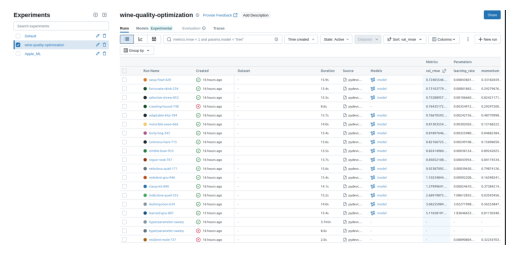

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Specify the path to your image file
image_path = "val_rmse.png"

# Read the image
img = mpimg.imread(image_path)

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide the axes
plt.show()

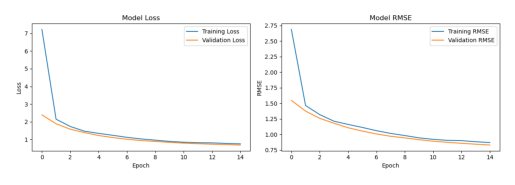

In [4]:

# Specify the path to your image file
image_path = "training_curves.png"

# Read the image
img = mpimg.imread(image_path)

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide the axes
plt.show()

## Step 6: Register your best model

To find the best run: in the table view, click on the run with the lowest `val_rmse` then navigate to **model artifacts** and scroll to the "Artifacts" section. then register the model:

    - Go to "Models" tab in MLflow UI

    - Click on your registered model

    - Transition to "Staging" stage for testing
    
    - Add tags and descriptions as needed


## Step 7: Deploy the best model

Test your model with a REST API

```
# Serve the model (choose the version number you registered)
mlflow models serve -m "models:/wine-quality-predictor/1" --port 5002
```

Test your deployment

```
# Test with a sample wine
curl -X POST http://localhost:5002/invocations \
  -H "Content-Type: application/json" \
  -d '{
    "dataframe_split": {
      "columns": [
        "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
        "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
        "pH", "sulphates", "alcohol"
      ],
      "data": [[7.0, 0.27, 0.36, 20.7, 0.045, 45, 170, 1.001, 3.0, 0.45, 8.8]]
    }
  }'


```


You could also test with Python

```

import requests
import json

# Prepare test data
test_wine = {
    "dataframe_split": {
        "columns": [
            "fixed acidity",
            "volatile acidity",
            "citric acid",
            "residual sugar",
            "chlorides",
            "free sulfur dioxide",
            "total sulfur dioxide",
            "density",
            "pH",
            "sulphates",
            "alcohol",
        ],
        "data": [[7.0, 0.27, 0.36, 20.7, 0.045, 45, 170, 1.001, 3.0, 0.45, 8.8]],
    }
}

# Make prediction request
response = requests.post(
    "http://localhost:5002/invocations",
    headers={"Content-Type": "application/json"},
    data=json.dumps(test_wine),
)

prediction = response.json()
print(f"Predicted wine quality: {prediction['predictions'][0]:.2f}")

```

## Step 8: Build a production Docker container

```
# Build Docker image
mlflow models build-docker \
  --model-uri "models:/wine-quality-predictor/1" \
  --name "wine-quality-api"
  ```

  Test your container:

  ```
# Run the container
docker run -p 5003:8080 wine-quality-api

# Test in another terminal
curl -X POST http://localhost:5003/invocations \
  -H "Content-Type: application/json" \
  -d '{
    "dataframe_split": {
      "columns": ["fixed acidity","volatile acidity","citric acid","residual sugar","chlorides","free sulfur dioxide","total sulfur dioxide","density","pH","sulphates","alcohol"],
      "data": [[7.0, 0.27, 0.36, 20.7, 0.045, 45, 170, 1.001, 3.0, 0.45, 8.8]]
    }
  }'
  ```


## Step 9: Deploy to Google cloud

1. Authentication and project set up

    $ `gcloud auth login`
2.  Configure Docker for gcp
    $ `gcloud auth configure-docker`

    set project
    $ `gcloud config set project PROJECT_ID`

3. IAM roles

    - Artifacr registry Administrator
    - roles/artifactregistry.createOnPushRepoAdmin
    - Storage Administrator
4. Export the credentials
    `export GOOGLE_APPLICATION_CREDENTIALS="/path/to/your-service-account-file.json"`
5. Tag the docker image

    $ `docker tag IMAGE_NAME gcr.io/PROJECT_ID/IMAGE_NAME:TAG`

6. Push the docker image to Google Cloud Container Registry
        $ `docker push gcr.io/PROJECT_ID/IMAGE_NAME:TAG`

[see](https://www.youtube.com/watch?v=D1_FC6pGutQ&ab_channel=TechWithOtabek)